# Tuning hyperparameters

Set directory

In [1]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

Load data:

In [ ]:
from Modules.read_data import read_data
import pandas as pd
from pathlib import Path

(
    DK1_train,
    DK1_test,
    DK2_train,
    DK2_test,
    DK1_train_weather,
    DK1_test_weather,
    DK2_train_weather,
    DK2_test_weather
) = read_data("combined_data_cleaned_v5.csv")


def _load_feature_predictions_for_zone(zone):
    prediction_path = Path(project_root) / "Data" / f"feature_predictions_{zone}_2024-2025.csv"
    if not prediction_path.exists():
        print("No precomputed forecasts found.")
        return None

    predictions = pd.read_csv(prediction_path, decimal=",", parse_dates=["Time"])
    predictions = predictions.loc[:, ~predictions.columns.duplicated()].copy()
    if "DKZone" in predictions.columns:
        predictions = predictions.loc[predictions["DKZone"] == zone].copy()
    return predictions


dk1_feature_predictions = _load_feature_predictions_for_zone("DK1")
dk2_feature_predictions = _load_feature_predictions_for_zone("DK2")
if (dk1_feature_predictions is not None) and (dk2_feature_predictions is not None):
    print("\nPrecomputed forecasts loaded.")

dk1_use_precomputed_feature_values = dk1_feature_predictions is not None
dk2_use_precomputed_feature_values = dk2_feature_predictions is not None

Notebook_dir: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Modules
Python_dir: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode
Data_folder: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Data
Training data shape (DK1): (78888, 38)
Test data shape (DK1): (8760, 38)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78888, 38)
Test data shape (DK2): (8760, 38)
Test set fraction (DK2): 9.99%
Precomputed forecasts loaded.


## Choose validation setup


**Setup 1**

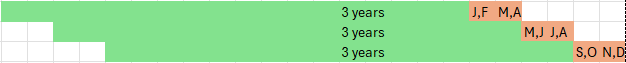

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

In [5]:
setup = 2

Import models

In [6]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from Modules.Load_RF_forecast_models import load_rf_models

rf_models = None
if not (dk1_use_precomputed_feature_values and dk2_use_precomputed_feature_values):
    # load_rf_models currently supports only the optional timeout argument.
    rf_models = load_rf_models(user="Nikolaj")      # set user to "Nikolaj" or "Christine"

# Initialize model:
model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1
)


In [7]:
from skforecast.exceptions import IgnoredArgumentWarning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Raw feature columns are present")
warnings.filterwarnings("ignore", category=UserWarning, message="Some categorized features not in dataset")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

## Find best parameters

### Hyperparameter search for DK1:

See train / val split

In [5]:
import pandas as pd
from Modules.Validation2 import _build_validation_folds

folds = _build_validation_folds(
    data=DK1_train,
    train_window=3 * 8760,        # 8760 hours = 1 year
    val_window=8784,
    val_start="2024-01-01 00:00:00",
    predict_period=4 * 168,         # 168 hours = 1 week
    stride=13 * 168,               # stride between predict_periods              
)

train_start = folds[0]["train_start"]
train_end = folds[0]["train_end"]
num_folds = len(folds)
val_start = folds[0]["val_start"]
val_end = val_start + pd.Timedelta(hours=8760 - 1)
prediction_period = folds[0]["val_end"] - folds[0]["val_start"] + pd.Timedelta(hours=1)

print(f"Fold {folds[0]['fold']} train start: {train_start} - train end: {train_end}")
print(f"Fold {folds[1]['fold']} train start: {folds[1]['train_start']} - train end: {folds[1]['train_end']}")
print(f"Number of folds: {num_folds}")
print(f"Validation window start: {val_start} - validation window end: {val_end}")
print(f"Prediction period: {prediction_period}")
for fold in range(len(folds)):
    print(f"Fold {folds[fold]['fold']} val start: {folds[fold]['val_start']} - val end: {folds[fold]['val_end']}")
# print(f"Fold {folds[1]['fold']} val start: {folds[1]['val_start']} - val end: {folds[1]['val_end']}")

Fold 1 train start: 2021-01-01 00:00:00 - train end: 2023-12-31 23:00:00
Fold 2 train start: 2021-01-01 00:00:00 - train end: 2023-12-31 23:00:00
Number of folds: 4
Validation window start: 2024-01-01 00:00:00 - validation window end: 2024-12-30 23:00:00
Prediction period: 28 days 00:00:00
Fold 1 val start: 2024-01-01 00:00:00 - val end: 2024-01-28 23:00:00
Fold 2 val start: 2024-04-01 00:00:00 - val end: 2024-04-28 23:00:00
Fold 3 val start: 2024-07-01 00:00:00 - val end: 2024-07-28 23:00:00
Fold 4 val start: 2024-09-30 00:00:00 - val end: 2024-10-27 23:00:00


c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\py_3.10_blackwell\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Run Cross-Validation

(Remember to give the right path to save the csv with results!)

In [10]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

# Keep at least one number in each list to avoid wrong calculation of total combinations
# If a parameter is not relevant just set a 0 in the list
param_grid = {
    "n_estimators": [50, 200, 500],
    "learning_rate": [0.01, 0.1],
    "num_leaves": [15, 63, 127],            # 15 = 2^4-1, 63 = 2^6-1, 127 = 2^7-1
    "max_depth": [-1],
    "min_child_samples": [1, 20, 50],
    "subsample": [0.8, 1.0],
    "subsample_freq": [1],
    "colsample_bytree": [1.0],
    "reg_alpha": [0.0],
    "reg_lambda": [0.0]
}

num_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK1_train,
        dk_zone = "DK1",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        val_window = 1 * 8784,
        val_start = "2024-01-01 00:00:00",
        predict_period = 4 * 168,     # 168 hours = 1 week
        stride = 13 * 168,               # stride between predict_periods              
        use_scaler = False,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly SMAPE values for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination?
        rf_models = rf_models,
        use_precomputed_feature_values = dk1_use_precomputed_feature_values,
        precomputed_feature_predictions = dk1_feature_predictions
    )

    row = {
        **params,
        "train_window": "3 years",
        "val_start": "2024-01-01",
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "LightGBM")
base_filename = "DK1_hyperparameter_search_results"          # Name the results file
filename = os.path.join(folder, f"{base_filename}.csv")

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))

Total number of combinations to test: 108

Combination 1/108: {'n_estimators': 50, 'learning_rate': 0.01, 'num_leaves': 15, 'max_depth': -1, 'min_child_samples': 1, 'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 1.0, 'reg_alpha': 0.0, 'reg_lambda': 0.0}
Training fold details: train_start=2021-01-01 00:00:00, train_end=2023-12-31 23:00:00, hours=26280, rows=26280, features=36
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001497 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7293
[LightGBM] [Info] Number of data points in the train set: 26280, number of used features: 36
[LightGBM] [Info] Start training from score 977.247323
Model trained in 0.07s. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 509.061

Average MAE across all weeks in all folds: 454.422

Average SMAPE across all weeks in all folds: 73.149

Combination 2/108: {'n_estimators': 50, 'learning_rate

### Hyperparameter search for DK2:

Remember to give the right path to save the csv with resutls!

In [7]:
param_grid = {
    "n_estimators": [50, 200, 500],
    "learning_rate": [0.01, 0.1],
    "num_leaves": [15, 63, 127],            # 15 = 2^4-1, 63 = 2^6-1, 127 = 2^7-1
    "max_depth": [-1],
    "min_child_samples": [1, 20, 50],
    "subsample": [0.8, 1.0],
    "subsample_freq": [1],
    "colsample_bytree": [1.0],
    "reg_alpha": [0.0],
    "reg_lambda": [0.0]
}


num_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Total number of combinations to test: {num_combinations}")

Total number of combinations to test: 108


In [ ]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK2_train,
        dk_zone = "DK2",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        val_window = 1 * 8760,
        val_start = "2024-01-01 00:00:00",
        predict_period = 4 * 168,     # 168 hours = 1 week
        stride = 13 * 168,               # stride between predict_periods              
        use_scaler = False,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly SMAPE values for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination?
        rf_models = rf_models,
        use_precomputed_feature_values = dk2_use_precomputed_feature_values,
        precomputed_feature_predictions = dk2_feature_predictions
    )

    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "LightGBM")
base_filename = "DK2_hyperparameter_search_results"          # Name the results file
filename = os.path.join(folder, f"{base_filename}.csv")

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))

Total number of combinations to test: 108

Combination 1/108: {'n_estimators': 50, 'learning_rate': 0.01, 'num_leaves': 15, 'max_depth': -1, 'min_child_samples': 1, 'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 1.0, 'reg_alpha': 0.0, 'reg_lambda': 0.0}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003832 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6770
[LightGBM] [Info] Number of data points in the train set: 26280, number of used features: 34
[LightGBM] [Info] Start training from score 940.819901
Model trained. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 473.870

Average MAE across all weeks in all folds: 413.631

Average SMAPE across all weeks in all folds: 69.430

Combination 2/108: {'n_estimators': 50, 'learning_rate': 0.01, 'num_leaves': 15, 'max_depth': -1, 'min_child_samples': 1, 'subsample': 1.0, 'subsample_freq': 1, 'colsample_bytree': 1.0, '

## Train and test final model

Make train and test periods

In [5]:
import pandas as pd
from Modules.Validation2 import _build_validation_folds

price_zone = "DK1"
if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

dataset = pd.concat([train_data, test_data], ignore_index=True)

folds = _build_validation_folds(
    data=dataset,
    train_window=len(train_data),        
    val_window=len(test_data),
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data),         # 168 hours = 1 week
    stride=len(test_data),               # stride between predict_periods              
)

train_start = folds[0]["train_start"]
train_end = folds[0]["train_end"]
num_folds = len(folds)
val_start = folds[0]["val_start"]
val_end = val_start + pd.Timedelta(hours=len(test_data) - 1)
prediction_period = folds[0]["val_end"] - folds[0]["val_start"] + pd.Timedelta(hours=1)

print(f"Fold {folds[0]['fold']} train start: {train_start} - train end: {train_end}")
print(f"Number of folds: {num_folds}")
print(f"Test window start: {val_start} - test window end: {val_end}")
print(f"Prediction period: {prediction_period}")
for fold in range(len(folds)):
    print(f"Fold {folds[fold]['fold']} test start: {folds[fold]['val_start']} - test end: {folds[fold]['val_end']}")

Fold 1 train start: 2016-01-02 00:00:00 - train end: 2024-12-31 23:00:00
Number of folds: 1
Test window start: 2025-01-01 00:00:00 - test window end: 2025-12-31 23:00:00
Prediction period: 365 days 00:00:00
Fold 1 test start: 2025-01-01 00:00:00 - test end: 2025-12-31 23:00:00


c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\py_3.10_blackwell\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train and test the final model

Training final model. This may take a while...
Training fold details: train_start=2016-01-03 00:00:00, train_end=2024-12-31 23:00:00, hours=78864, rows=78864, features=36
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003979 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7445
[LightGBM] [Info] Number of data points in the train set: 78864, number of used features: 36
[LightGBM] [Info] Start training from score 520.373399
Model trained in 0.39s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 376.248

Average MAE across all weeks in all folds: 302.719

Average SMAPE across all weeks in all folds: 60.732


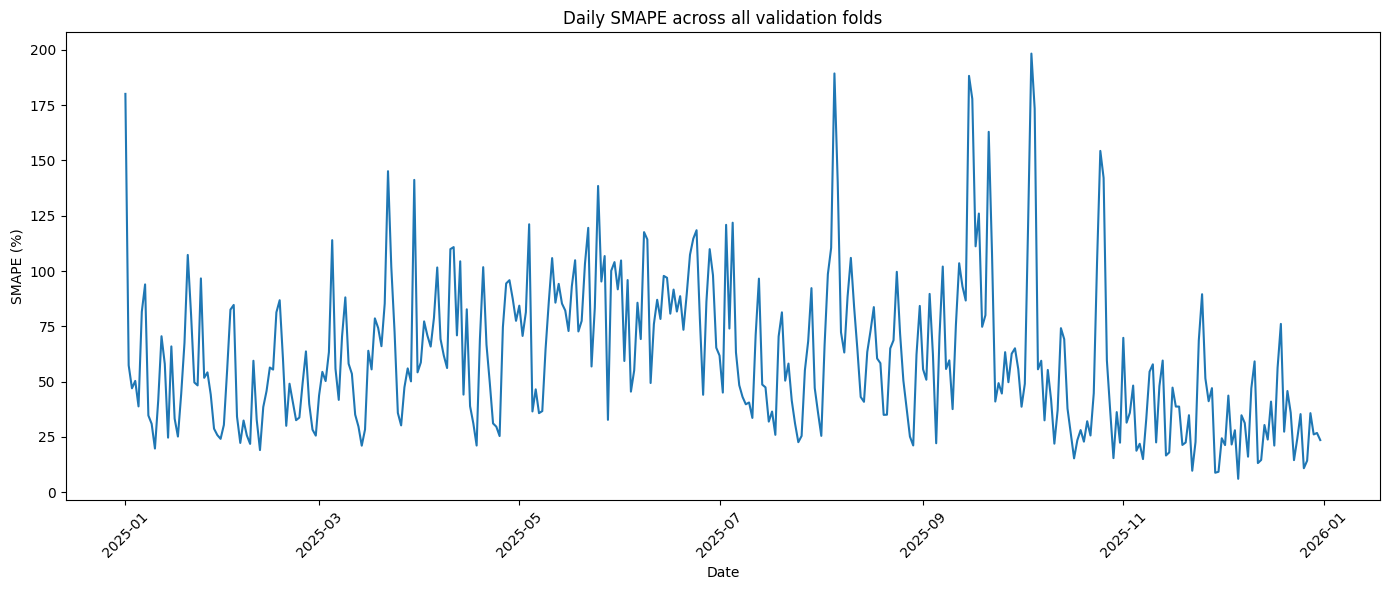

Fitted LightGBM booster trees: 200
Trained model saved to: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Shallow learners\LightGBM\LightGBM_final_model_DK1.joblib


In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from lightgbm import LGBMRegressor
from Modules.Validation2 import run_cross_validation
import os

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = True  # Keep False to avoid multi-GB model files

param_grid = {
    "n_estimators": [200],
    "learning_rate": [0.01],
    "num_leaves": [15],            # 15 = 2^4-1, 63 = 2^6-1, 127 = 2^7-1
    "max_depth": [-1],
    "min_child_samples": [1],
    "subsample": [0.8],
    "subsample_freq": [1],
    "colsample_bytree": [1.0],
    "reg_alpha": [0.0],
    "reg_lambda": [0.0]
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)

params = {key: values[0] for key, values in param_grid.items()}
model.set_params(**params)

# Save model in the same folder as this notebook/script (LightGBM folder)
model_dir = Path(project_root) / "Shallow learners" / "LightGBM"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"LightGBM_final_model_{price_zone}.joblib"

results = []

if model_path.exists() and not retrain_model and save_model_to_disk:
    print(f"Loading existing trained model: {model_path}")
    model = joblib.load(model_path)
    print("Model loaded. Skipping retraining.")
else:
    print("Training final model. This may take a while...")
    model.set_params(**params)

    combination_results = run_cross_validation(
        model=model,
        dataset=dataset,
        dk_zone=price_zone,
        split_setup=2,                          # ignored in Validation2 but safe to keep
        train_window=8*8760 + 1*8784, #len(train_data),           # full training set
        val_window=len(test_data),              # full test set
        val_start=str(test_data["Time"].min()),
        predict_period=len(test_data),          # one fold covering full test period
        stride=len(test_data),
        use_scaler=False,
        print_fold_results=False,
        plot=True,
        rf_models=rf_models,
        use_precomputed_feature_values=use_precomputed_feature_values,
        precomputed_feature_predictions=feature_predictions,
    )

    # Extract the fitted model
    model = combination_results["model"]

    if not hasattr(model, "booster_") or model.booster_ is None:
        raise ValueError("Training finished, but model has no booster_. Model is not fitted.")
    print(f"Fitted LightGBM booster trees: {model.booster_.num_trees()}")

    fold_results_df = combination_results["fold_results"]
    train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
    train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

    row = {
        **params,
        "train_start": train_start_period,
        "train_end": train_end_period,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

    # Save the search results as a CSV file in chosen folder path:
    results_df = pd.DataFrame(results).sort_values("avg_smape")
    folder = os.path.join(project_root, "Shallow learners")
    folder = os.path.join(folder, "LightGBM")
    base_filename = f"{price_zone}_final_LightGBM_9years_results"
    filename = os.path.join(folder, f"{base_filename}.csv")

    # adds a number to the filename if a file with same name already exists:
    counter = 1
    while os.path.exists(filename):
        filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
        counter += 1
    results_df.to_csv(filename, index=False, decimal=",")

    if save_model_to_disk:
        # Compression reduces disk usage considerably at the cost of slower save/load
        joblib.dump(model, model_path, compress=3)
        print(f"Trained model saved to: {model_path}")
    else:
        print("Model persistence disabled (save_model_to_disk=False).")

SHAP analysis

Using fitted LightGBM booster with 200 trees
Available RAM before SHAP: 16.18 GB
Training set size for SHAP: 78888 samples
Number of features: 36

Background sample size (X_bg): 1000
Evaluation sample size (X_eval): 2000
Chunk size: 10
Computing SHAP chunk 1/200 (rows 0:10)...
Computing SHAP chunk 2/200 (rows 10:20)...
Computing SHAP chunk 3/200 (rows 20:30)...
Computing SHAP chunk 4/200 (rows 30:40)...
Computing SHAP chunk 5/200 (rows 40:50)...
Computing SHAP chunk 6/200 (rows 50:60)...
Computing SHAP chunk 7/200 (rows 60:70)...
Computing SHAP chunk 8/200 (rows 70:80)...
Computing SHAP chunk 9/200 (rows 80:90)...
Computing SHAP chunk 10/200 (rows 90:100)...
Computing SHAP chunk 11/200 (rows 100:110)...
Computing SHAP chunk 12/200 (rows 110:120)...
Computing SHAP chunk 13/200 (rows 120:130)...
Computing SHAP chunk 14/200 (rows 130:140)...
Computing SHAP chunk 15/200 (rows 140:150)...
Computing SHAP chunk 16/200 (rows 150:160)...
Computing SHAP chunk 17/200 (rows 160:170)...
Computing S

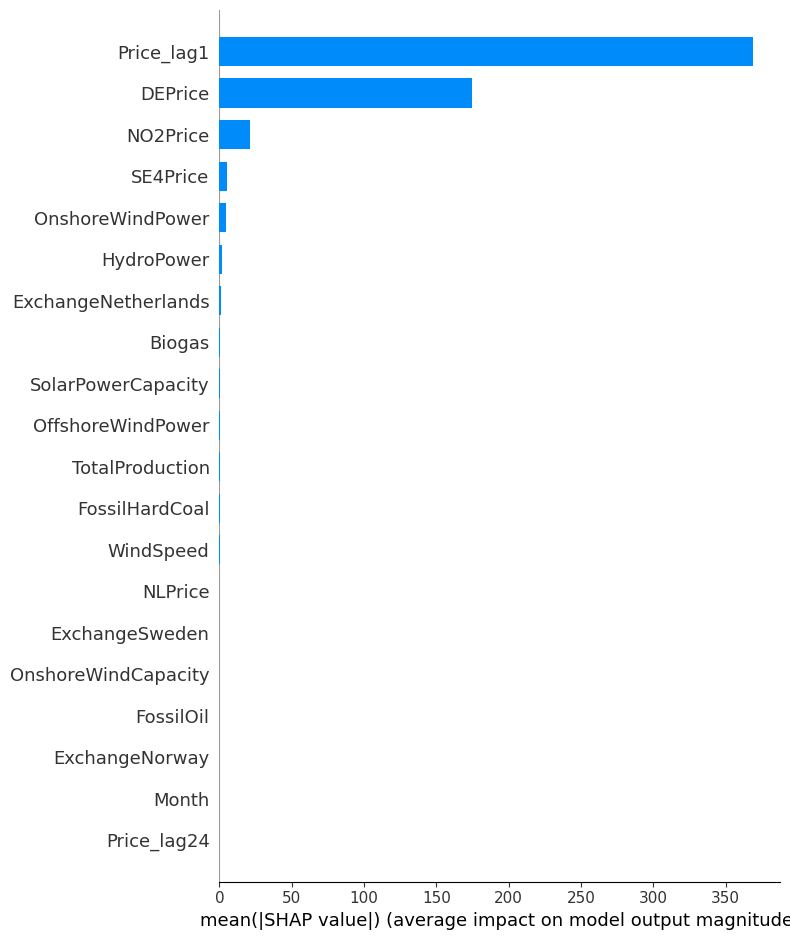

<Figure size 640x480 with 0 Axes>

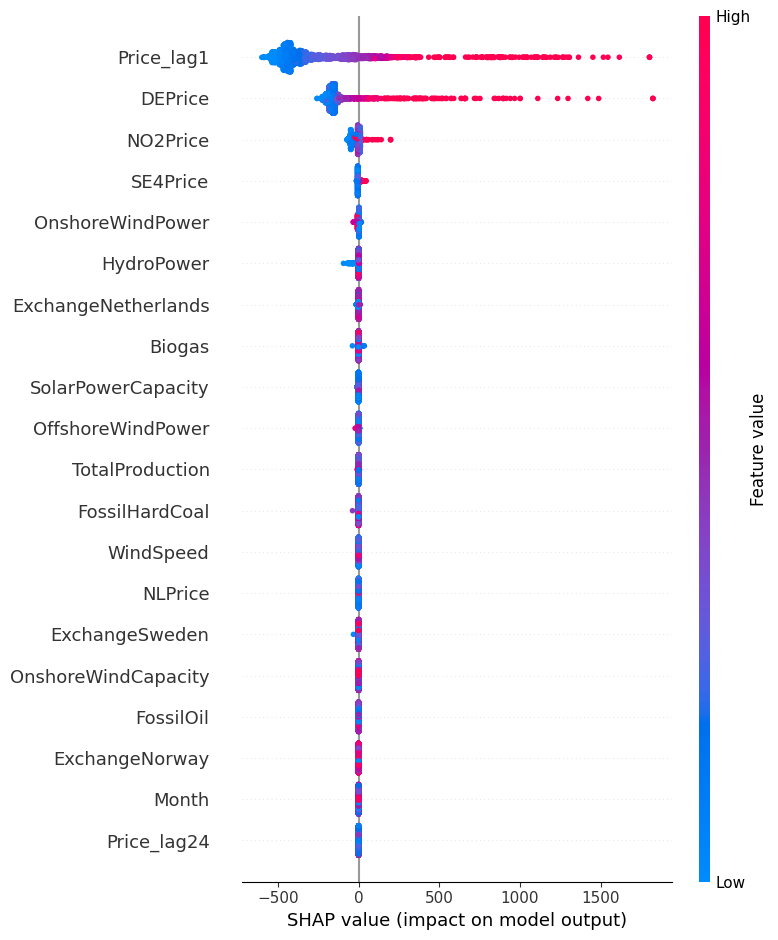

<Figure size 640x480 with 0 Axes>

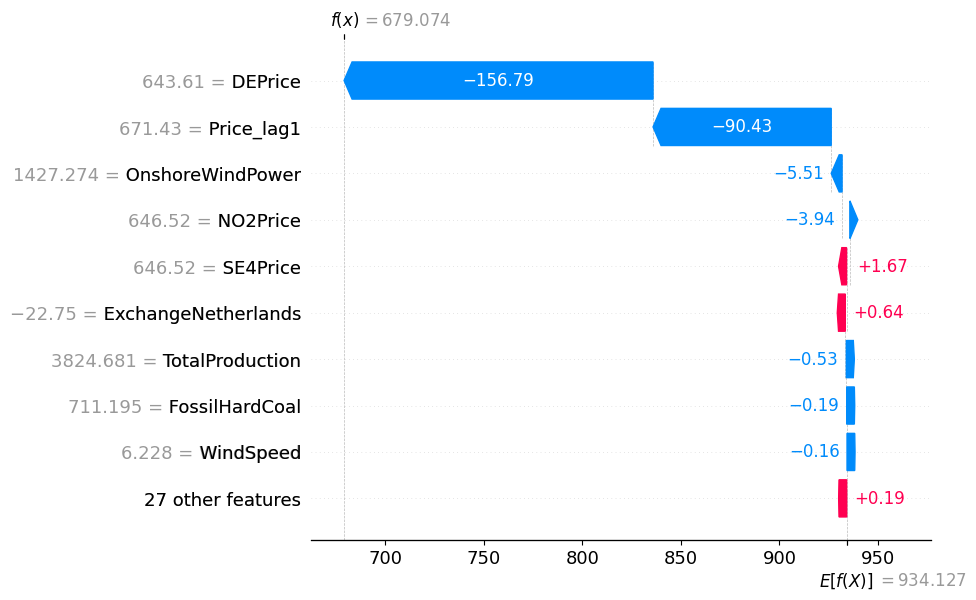

<Figure size 640x480 with 0 Axes>

Available RAM while running SHAP: 16.15 GB
Available RAM after SHAP cleanup: 16.17 GB


In [12]:
import gc
from pathlib import Path
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

# ==========================
# SHAP configuration (easy to tune)
# ==========================
quick_mode = False
eval_size = 2000            # <- Evaluation sample size: number of rows to analyse
bg_size = 1000              # <- Background sample size: used to compute expected values
chunk_size = 10             # <- Lower if memory issues
include_beeswarm = True
include_waterfall = True
joblib_file = "LightGBM_final_model_*.joblib"  # Fallback search pattern in current folder

# Auto-load model if it is missing from memory
if "model" not in globals():
    if "project_root" not in globals():
        raise ValueError("Missing 'project_root'. Run 'Set directory' cell first.")

    model_dir = Path(project_root) / "Shallow learners" / "LightGBM"
    model_path = None

    # Prefer current price_zone if available
    if "price_zone" in globals():
        preferred = model_dir / f"LightGBM_final_model_{price_zone}.joblib"
        if preferred.exists():
            model_path = preferred

    # Otherwise load the newest .joblib that matches the pattern
    if model_path is None:
        candidates = sorted(model_dir.glob(joblib_file), key=lambda p: p.stat().st_mtime, reverse=True)
        if candidates:
            model_path = candidates[0]

    if model_path is None or not model_path.exists():
        raise ValueError(f"No .joblib model found in {model_dir}. Train once or place model file there.")

    model = joblib.load(model_path)
    print(f"Loaded model from disk: {model_path}")

required_vars = ["dataset", "folds"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(
        f"Missing required variables: {missing}. Run 'Make train and test periods' cell first."
    )

# Confirm model is fitted (LightGBM exposes booster_ after fit)
if not hasattr(model, "booster_") or model.booster_ is None:
    raise ValueError("Loaded model is not fitted. Train final model first.")
print(f"Using fitted LightGBM booster with {model.booster_.num_trees()} trees")

# Rebuild the same training frame used for fitting
data = dataset.copy().sort_values("Time").reset_index(drop=True)
feature_columns = [c for c in data.columns[1:] if c != "Time"]

first_fold = folds[0]
train_mask = (data["Time"] >= first_fold["train_start"]) & (data["Time"] <= first_fold["train_end"])
X_train_shap = data.loc[train_mask, feature_columns].copy()

if len(X_train_shap) == 0:
    raise ValueError("No rows found for SHAP training slice. Check folds and dataset alignment.")

# Downcast to reduce memory pressure
X_train_shap = X_train_shap.astype(np.float32, copy=False)

mem = psutil.virtual_memory()
print(f"Available RAM before SHAP: {mem.available / (1024**3):.2f} GB")
print(f"Training set size for SHAP: {len(X_train_shap)} samples")
print(f"Number of features: {len(feature_columns)}")

if quick_mode:
    bg_size = min(20, len(X_train_shap))
    eval_size = min(40, len(X_train_shap))
    chunk_size = 5
else:
    bg_size = min(bg_size, len(X_train_shap))
    eval_size = min(eval_size, len(X_train_shap))
    chunk_size = max(1, min(chunk_size, eval_size))

X_bg = shap.sample(X_train_shap, bg_size, random_state=42)
X_eval = shap.sample(X_train_shap, eval_size, random_state=42)

print(f"\nBackground sample size (X_bg): {len(X_bg)}")
print(f"Evaluation sample size (X_eval): {len(X_eval)}")
print(f"Chunk size: {chunk_size}")

explainer = shap.TreeExplainer(
    model,
    feature_perturbation="tree_path_dependent",
    model_output="raw"
)

# Compute SHAP values in chunks and print progress
shap_chunks = []
n_chunks = (len(X_eval) + chunk_size - 1) // chunk_size
for idx, start in enumerate(range(0, len(X_eval), chunk_size), start=1):
    stop = min(start + chunk_size, len(X_eval))
    print(f"Computing SHAP chunk {idx}/{n_chunks} (rows {start}:{stop})...", flush=True)
    X_chunk = X_eval.iloc[start:stop]
    shap_chunk = explainer.shap_values(
        X_chunk,
        check_additivity=False
    )
    shap_chunks.append(shap_chunk)

shap_values = np.vstack(shap_chunks)
gc.collect()

print("\nSHAP analysis complete.")

# Global importance
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_eval, plot_type="bar", show=True)
plt.tight_layout()
plt.show()
plt.close()

if include_beeswarm:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_eval, show=True)
    plt.tight_layout()
    plt.show()
    plt.close()

if include_waterfall:
    i = 0
    base_value = explainer.expected_value
    if isinstance(base_value, (list, tuple, np.ndarray)):
        base_value = np.array(base_value).reshape(-1)[0]

    plt.figure(figsize=(10, 4))
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[i],
            base_values=base_value,
            data=X_eval.iloc[i].values,
            feature_names=X_eval.columns.tolist()
        )
    )
    plt.tight_layout()
    plt.show()
    plt.close()

mem_while_running = psutil.virtual_memory()
print(f"Available RAM while running SHAP: {mem_while_running.available / (1024**3):.2f} GB")

# Cleanup large objects explicitly
del X_bg, X_eval, X_train_shap, shap_chunks, shap_values
gc.collect()

mem_after = psutil.virtual_memory()
print(f"Available RAM after SHAP cleanup: {mem_after.available / (1024**3):.2f} GB")